# Načtení dat

In [1]:
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import optuna

from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, AutoARIMA
from typing import Callable, List, Type

In [2]:
# Load dataset
df = pd.read_csv("data/dataset_ml.csv", sep=';', parse_dates=['date'], date_format='%d.%m.%Y')

dates_sorted = sorted(df['date'].unique())
holdout_dates = dates_sorted[-4:]           # 2024 Q1–Q4
cutoff_date = holdout_dates[0]              # 2024-03-31

df_train = df[df['date'] < cutoff_date].copy()    # training data (2019 Q1 – 2023 Q4)
df_holdout = df[df['date'] >= cutoff_date].copy() # holdout data  (2024 Q1 – 2024 Q4)

print(f"Training set ends at:  {df_train['date'].max().date()}")
print(f"Holdout set starts at: {df_holdout['date'].min().date()}")

df.head(10)

Training set ends at:  2023-12-31
Holdout set starts at: 2024-03-31


,region,date,price
0,praha,2019-03-31,73818
1,praha,2019-06-30,75162
2,praha,2019-09-30,77202
3,praha,2019-12-31,79382
4,stredocesky,2019-03-31,28777
5,stredocesky,2019-06-30,31328
6,stredocesky,2019-09-30,31846
7,stredocesky,2019-12-31,32882
8,jihocesky,2019-03-31,26028
9,jihocesky,2019-06-30,26896


In [3]:
# Prague only
only_prague = df_train[df_train["region"] == "praha"]
one_length = len(only_prague)
print(one_length)
print(only_prague)

20
    region       date   price
0    praha 2019-03-31   73818
1    praha 2019-06-30   75162
2    praha 2019-09-30   77202
3    praha 2019-12-31   79382
56   praha 2020-03-31   82409
57   praha 2020-06-30   84096
58   praha 2020-09-30   88315
59   praha 2020-12-31   88315
112  praha 2021-03-31   93413
113  praha 2021-06-30   96950
114  praha 2021-09-30  103196
115  praha 2021-12-31  109350
168  praha 2022-03-31  110995
169  praha 2022-06-30  114746
170  praha 2022-09-30  114792
171  praha 2022-12-31  110171
224  praha 2023-03-31  103549
225  praha 2023-06-30  103992
226  praha 2023-09-30  103859
227  praha 2023-12-31  103372


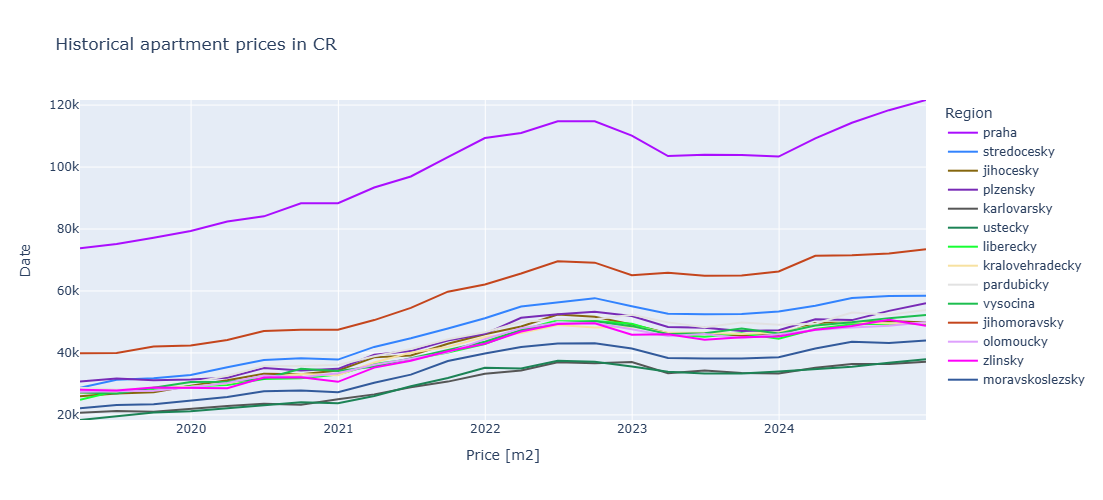

In [4]:
fig = px.line(
    df,
    x="date",
    y="price",
    color="region",
    title="Historical apartment prices in CR",
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

fig.update_yaxes(range=[df["price"].min(), df["price"].max()])

fig.update_layout(
    autosize=True,
    height=500,
    xaxis_title="Price [m2]",
    yaxis_title="Date",
    legend_title="Region"
)

fig.show()

In [5]:
all_prices = df.pivot(index="date", columns="region", values="price").reset_index()
all_prices.describe()

region,date,jihocesky,jihomoravsky,karlovarsky,kralovehradecky,liberecky,moravskoslezsky,olomoucky,pardubicky,plzensky,praha,stredocesky,ustecky,vysocina,zlinsky
count,24,24.000000,24.000000,24.000000,24.00000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2022-02-13 18:00:00,41406.625000,58228.958333,30183.208333,40865.00000,40396.500000,34911.333333,40459.750000,43229.291667,43448.750000,99193.333333,46866.166667,30034.958333,41173.375000,40060.333333
min,2019-03-31 00:00:00,26028.000000,39865.000000,20701.000000,27075.00000,24875.000000,22170.000000,27515.000000,28214.000000,30769.000000,73818.000000,28777.000000,18357.000000,26948.000000,27871.000000
25%,2020-09-07 00:00:00,33230.750000,47354.750000,23549.750000,32652.50000,31802.250000,27537.000000,32601.750000,35761.000000,34728.500000,87260.250000,37832.250000,23662.750000,33558.500000,31711.500000
50%,2022-02-14 00:00:00,45710.500000,63519.500000,33311.500000,45609.00000,43760.500000,38222.000000,44611.000000,47488.500000,46640.000000,103460.500000,51836.500000,33369.500000,44886.500000,43609.500000
75%,2023-07-23 00:00:00,49282.500000,67018.250000,35501.500000,48294.00000,48081.250000,41576.250000,47732.500000,50212.750000,50995.750000,110377.000000,55122.250000,35282.750000,48702.000000,47064.750000
max,2024-12-31 00:00:00,52378.000000,73451.000000,37144.000000,50018.00000,50588.000000,44031.000000,49880.000000,53864.000000,56063.000000,121643.000000,58474.000000,37944.000000,52256.000000,50700.000000
std,NaN,8911.729271,11718.000395,6146.296325,8435.44919,8723.873302,7744.180259,8331.739336,8968.796485,8688.045506,14786.199164,10088.469396,6648.853693,8660.524669,8361.397068


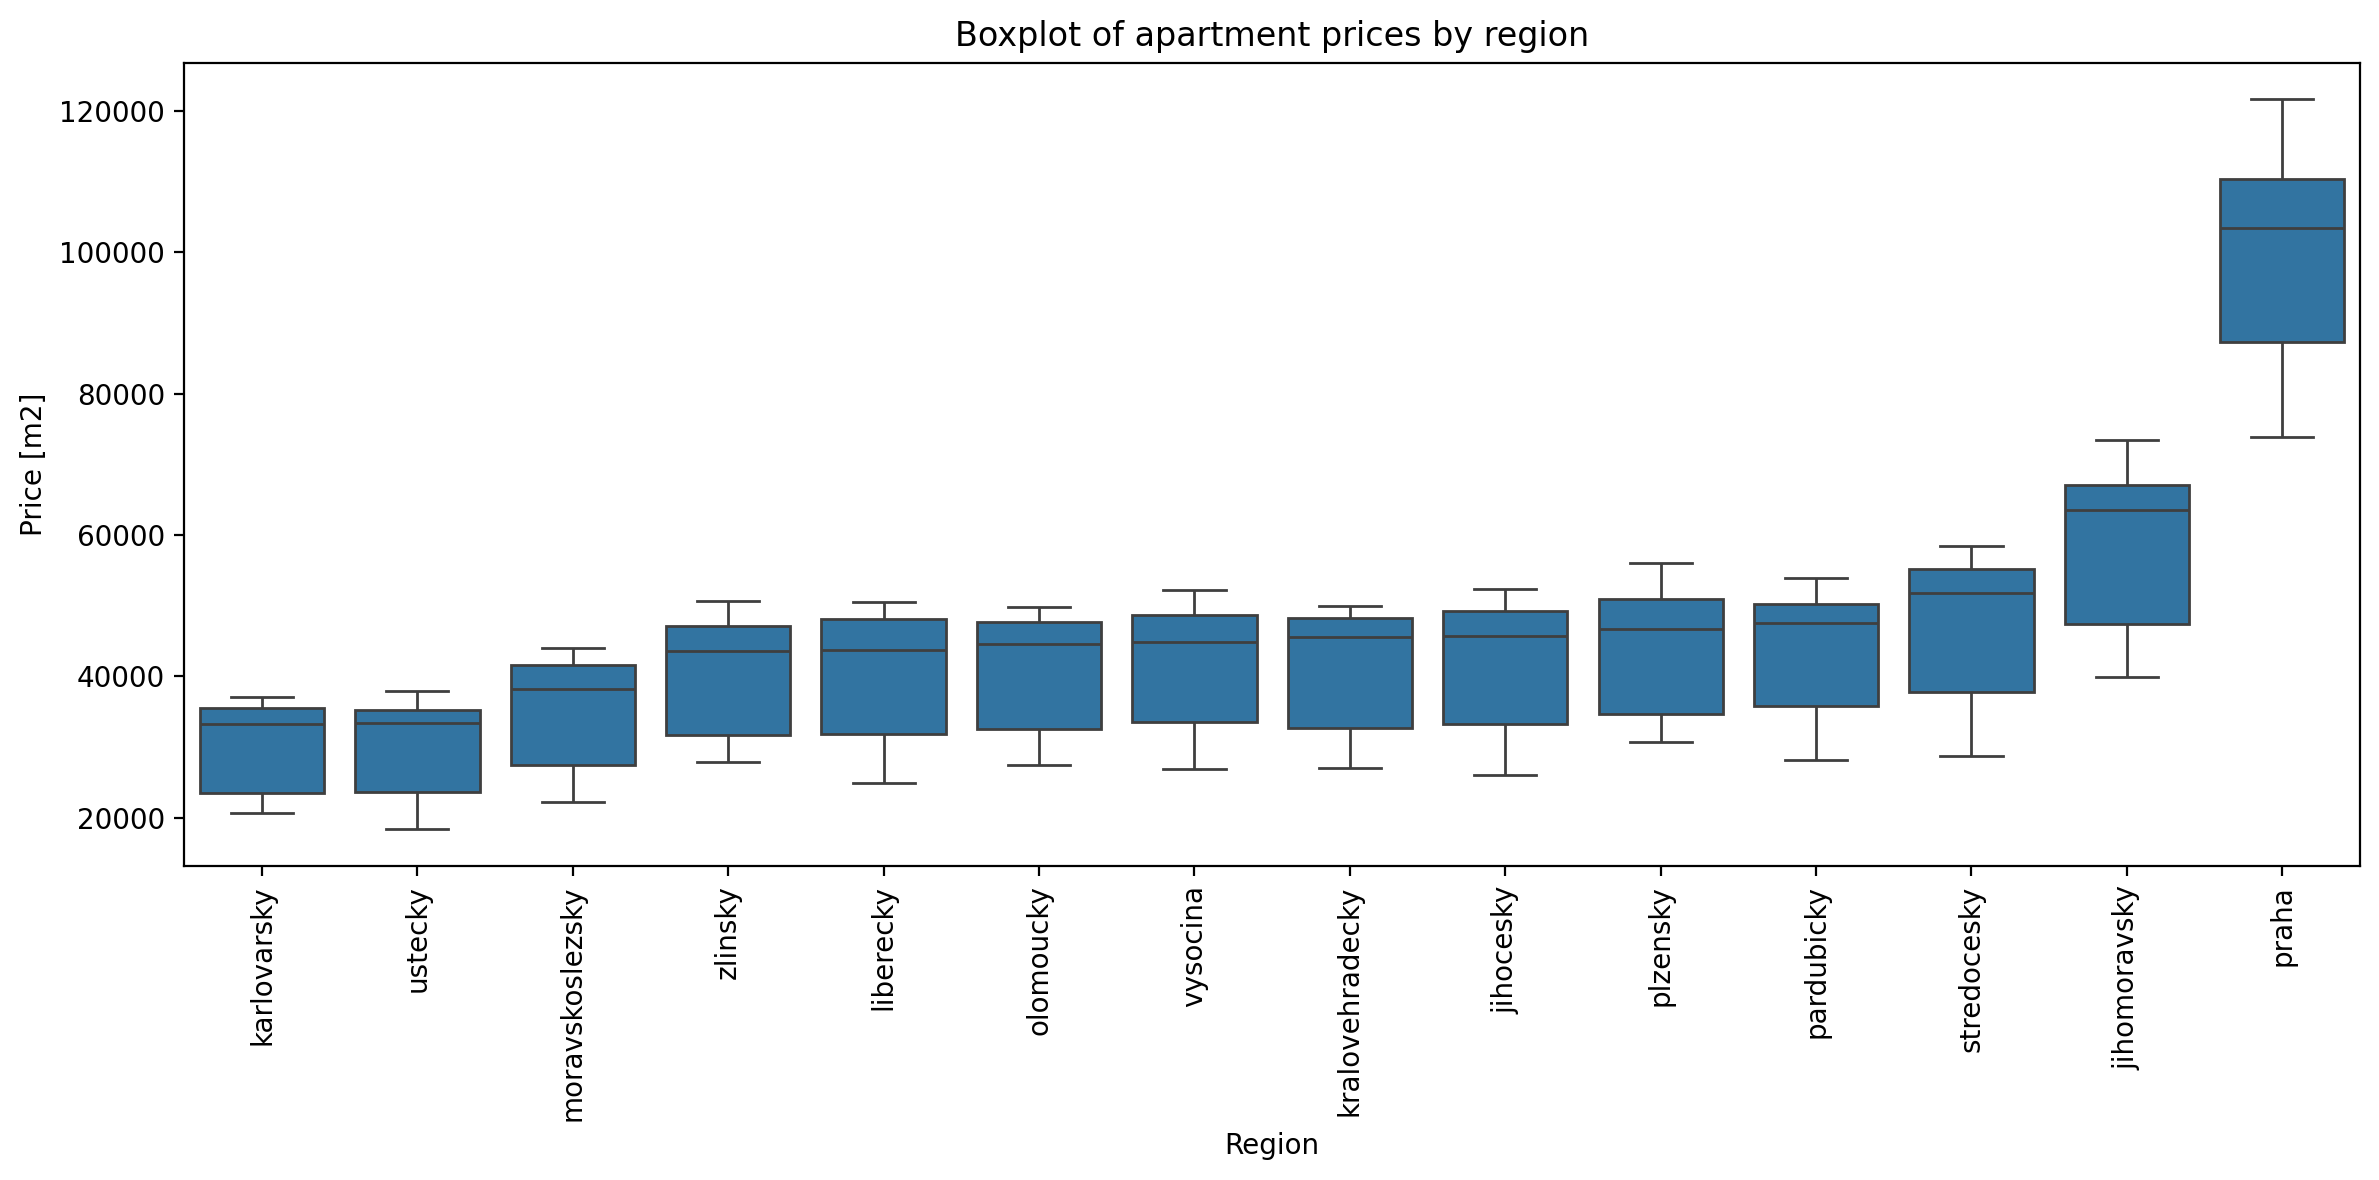

In [6]:
order = df.groupby("region")["price"].median().sort_values().index

plt.figure(figsize=(12, 6), dpi=200)
sns.boxplot(data=df, x="region", y="price", order=order)
plt.xticks(rotation=90)
plt.xlabel("Region")
plt.ylabel("Price [m2]")
plt.title("Boxplot of apartment prices by region")
plt.tight_layout()
plt.show()

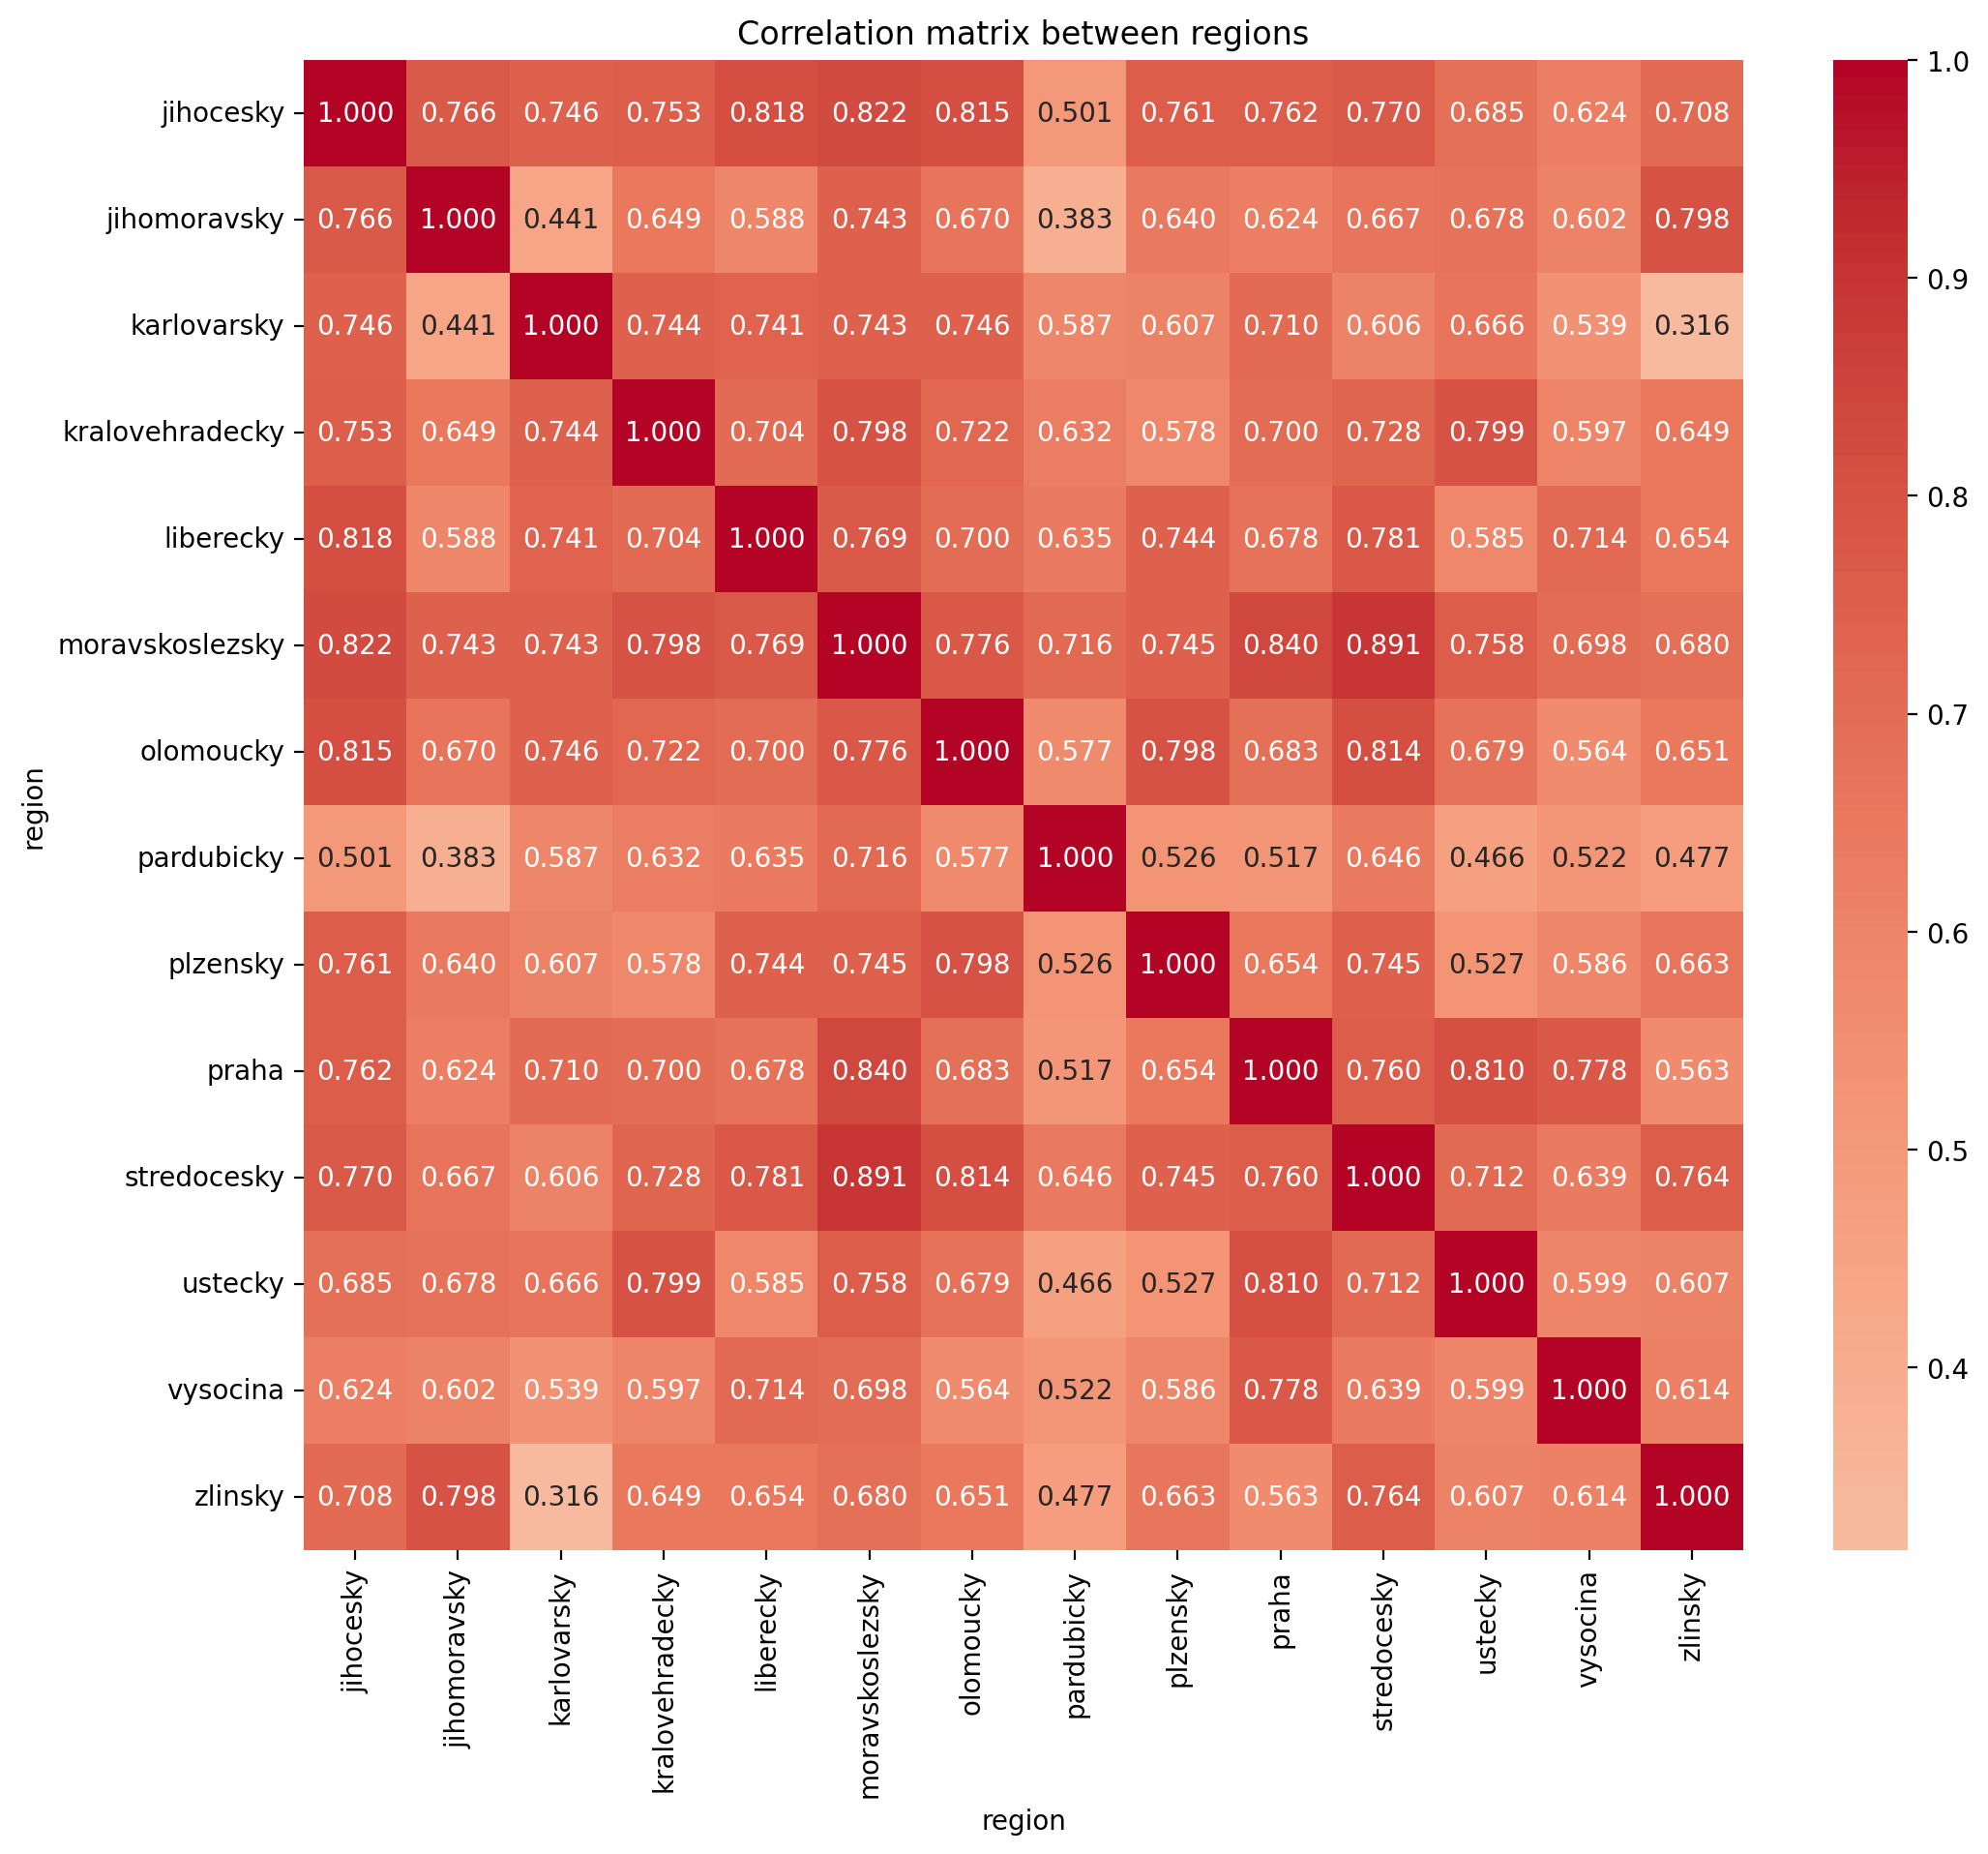

In [7]:
all_prices_diff = all_prices.set_index("date").diff().dropna()
corr_matrix = all_prices_diff.corr()

plt.figure(figsize=(12, 10), dpi=200)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix between regions")
plt.show()

In [8]:
def add_correlation_features(df: pd.DataFrame, corr_matrix: pd.DataFrame, top_n: int = 3) -> pd.DataFrame:
    df = df.copy()
    regions = df['region'].unique()
    wide = df.pivot(index='date', columns='region', values='price')
    wide_diff = wide.diff()
    
    for region in regions:
        top_correlated = (corr_matrix[region]
                          .drop(region)
                          .nlargest(top_n)
                          .index.tolist())
        weights = corr_matrix[region][top_correlated]
        weights = weights / weights.sum()
        weighted_change = (wide_diff[top_correlated] * weights).sum(axis=1)
        
        mask = df['region'] == region
        df.loc[mask, 'corr_neighbors_change'] = df.loc[mask, 'date'].map(weighted_change)
    
    df['corr_neighbors_change_lag1'] = (df
                                        .groupby('region')['corr_neighbors_change']
                                        .shift(1)
                                        .fillna(0))

    df = df.drop(columns=['corr_neighbors_change'])
    
    return df

In [9]:
df = add_correlation_features(df, corr_matrix, top_n=3)
df_train = add_correlation_features(df_train, corr_matrix, top_n=3)

print(df_train[['region', 'date', 'corr_neighbors_change_lag1']].head(10))

        region       date  corr_neighbors_change_lag1
0        praha 2019-03-31                    0.000000
1        praha 2019-06-30                    0.000000
2        praha 2019-09-30                  683.987205
3        praha 2019-12-31                 1043.097828
4  stredocesky 2019-03-31                    0.000000
5  stredocesky 2019-06-30                    0.000000
6  stredocesky 2019-09-30                 1344.570064
7  stredocesky 2019-12-31                  292.223701
8    jihocesky 2019-03-31                    0.000000
9    jihocesky 2019-06-30                    0.000000


# Model Evaluation

## Hyperparameters

In [10]:
lags = [1, 2, 3, 4] # last year
h = 1
step_size = 1

min_train_size = max(lags) + 2 # corr feature
max_num_windows = (one_length - min_train_size + h) // step_size
print(max_num_windows)

15


## Random Forest Regressor & XGBoost Hyperparameter Tuning

In [11]:
def tune_model(model_class: Type, param_func: Callable[[optuna.Trial], dict], n_trials: int=20) -> dict:
    model_name = model_class.__name__
    print(f"Initializing tuning for: {model_name}...")

    def objective(trial):
        params = param_func(trial)
        
        model = model_class(**params)
        
        mlf_tune = MLForecast(
            models=[model],
            freq='QE',
            lags=lags
        )
        
        cv_results = mlf_tune.cross_validation(
            df=df_train, 
            h=h, 
            step_size=step_size,
            n_windows=max_num_windows,
            id_col='region',
            time_col='date', 
            target_col='price',
            static_features=[]
        )
        
        error = mean_absolute_error(cv_results['price'], cv_results[model_name])
        return error

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"Tuning {model_name} completed. Best MAE: {study.best_value:.2f}")
    return study.best_params

In [12]:
def xgb_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 0,
        'n_jobs': -1
    }

def rf_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 0,
        'n_jobs': -1
    }

best_params_xgb = tune_model(XGBRegressor, xgb_params, 20)
best_params_rf = tune_model(RandomForestRegressor, rf_params, 20)

[I 2026-03-16 20:33:18,934] A new study created in memory with name: no-name-5b988e52-e834-47ae-b6b0-4edbed01ab1e


Initializing tuning for: XGBRegressor...


[I 2026-03-16 20:33:20,454] Trial 0 finished with value: 2651.10595703125 and parameters: {'n_estimators': 257, 'max_depth': 4, 'learning_rate': 0.013488715681251923, 'subsample': 0.5526717509055694, 'colsample_bytree': 0.5155155740488109}. Best is trial 0 with value: 2651.10595703125.
[I 2026-03-16 20:33:22,175] Trial 1 finished with value: 2310.169921875 and parameters: {'n_estimators': 183, 'max_depth': 6, 'learning_rate': 0.03226838162129575, 'subsample': 0.728463356673803, 'colsample_bytree': 0.5767285517695038}. Best is trial 1 with value: 2310.169921875.
[I 2026-03-16 20:33:23,689] Trial 2 finished with value: 3578.8046875 and parameters: {'n_estimators': 145, 'max_depth': 5, 'learning_rate': 0.01159456688613797, 'subsample': 0.9247462880226553, 'colsample_bytree': 0.9022640640518289}. Best is trial 1 with value: 2310.169921875.
[I 2026-03-16 20:33:25,209] Trial 3 finished with value: 2743.6875 and parameters: {'n_estimators': 258, 'max_depth': 4, 'learning_rate': 0.011411509288

Tuning XGBRegressor completed. Best MAE: 2147.63
Initializing tuning for: RandomForestRegressor...


[I 2026-03-16 20:33:53,995] Trial 0 finished with value: 3095.4267485061837 and parameters: {'n_estimators': 276, 'max_depth': 3, 'min_samples_split': 8}. Best is trial 0 with value: 3095.4267485061837.
[I 2026-03-16 20:34:00,178] Trial 1 finished with value: 2750.134218388922 and parameters: {'n_estimators': 296, 'max_depth': 3, 'min_samples_split': 2}. Best is trial 1 with value: 2750.134218388922.
[I 2026-03-16 20:34:06,135] Trial 2 finished with value: 3916.5243513375663 and parameters: {'n_estimators': 283, 'max_depth': 2, 'min_samples_split': 10}. Best is trial 1 with value: 2750.134218388922.
[I 2026-03-16 20:34:09,812] Trial 3 finished with value: 2471.8050093361276 and parameters: {'n_estimators': 161, 'max_depth': 6, 'min_samples_split': 3}. Best is trial 3 with value: 2471.8050093361276.
[I 2026-03-16 20:34:13,400] Trial 4 finished with value: 2637.415605573987 and parameters: {'n_estimators': 164, 'max_depth': 5, 'min_samples_split': 4}. Best is trial 3 with value: 2471.805

Tuning RandomForestRegressor completed. Best MAE: 2353.88


## Training

In [13]:
def add_horizon(cv_df: pd.DataFrame) -> pd.DataFrame:
    cv_df = cv_df.copy()
    cv_df['horizon'] = cv_df.groupby(['region', 'cutoff']).cumcount() + 1
    return cv_df

In [14]:
best_xgb = XGBRegressor(**best_params_xgb, random_state=0)
best_rf = RandomForestRegressor(**best_params_rf, random_state=0)

mlf = MLForecast(
    models=[
        LinearRegression(),
        best_xgb,
        best_rf
    ],
    freq='QE',
    lags=lags,
)

sf = StatsForecast(
    models=[
        Naive(), 
        HistoricAverage(), 
        WindowAverage(window_size=max(lags)),
        AutoARIMA(season_length=max(lags), approximation=True)
    ],
    freq='QE',
    n_jobs=-1,
)

h_cv = 4
max_num_windows_cv = (one_length - min_train_size - h_cv) // step_size
print(f"max_num_windows for h=4: {max_num_windows_cv}")

cv_results_ml = add_horizon(mlf.cross_validation(
    df=df_train, 
    h=h_cv, 
    step_size=step_size, 
    n_windows=max_num_windows_cv,
    id_col='region', 
    time_col='date', 
    target_col='price',
    static_features=[]
))

cv_results_stat = add_horizon(sf.cross_validation(
    df=df_train, 
    h=h_cv, 
    step_size=step_size, 
    n_windows=max_num_windows_cv,
    id_col='region', 
    time_col='date', 
    target_col='price',
))

max_num_windows for h=4: 10


## Results Analysis

In [15]:
def eval_by_horizon(cv_df: pd.DataFrame, model_cols: List[str]) -> pd.DataFrame:
    rows = []
    
    for model in model_cols:
        row = {'model': model}
        
        for h in range(1, 5):
            subset = cv_df[cv_df['horizon'] == h]
            
            mae = mean_absolute_error(subset['price'], subset[model])
            mae_pct = (mae / subset['price'].mean()) * 100
            rmse = np.sqrt(mean_squared_error(subset['price'], subset[model]))
            
            row[f'H{h} MAE'] = round(mae, 0)
            row[f'H{h} MAE%'] = round(mae_pct, 2)
            row[f'H{h} RMSE'] = round(rmse, 0)
            
        rows.append(row)
    return pd.DataFrame(rows).set_index('model')

In [16]:
ml_cols = [str(m) for m in mlf.models]
stat_cols = [m.alias for m in sf.models]

table_ml = eval_by_horizon(cv_results_ml, ml_cols)
table_stat = eval_by_horizon(cv_results_stat, stat_cols)

results_table = pd.concat([table_ml, table_stat])

display(results_table.style
    .format({
        col: '{:.2f}%' if 'MAE%' in col
        else '{:.0f}'
        for col in results_table.columns
    })
    .background_gradient(
        cmap='Blues', 
        axis=None,
        subset=[c for c in results_table.columns if 'MAE%' in c]
    )
    .background_gradient(
        cmap='Purples',
        axis=None,
        subset=[c for c in results_table.columns if 'RMSE' in c]
    )
    .set_caption("MAE and RMSE by forecast horizon (H1–H4)")
)

,H1 MAE,H1 MAE%,H1 RMSE,H2 MAE,H2 MAE%,H2 RMSE,H3 MAE,H3 MAE%,H3 RMSE,H4 MAE,H4 MAE%,H4 RMSE
model,,,,,,,,,,,,
LinearRegression,2135,4.45%,2610,3488,7.08%,4398,5023,10.01%,6140,6856,13.47%,8091
XGBRegressor,2455,5.12%,2951,4057,8.24%,4911,6005,11.96%,7099,7699,15.12%,9017
RandomForestRegressor,2592,5.40%,3234,4607,9.36%,5663,6670,13.29%,8052,8459,16.62%,10103
Naive,2327,4.85%,2735,4391,8.92%,4905,5920,11.80%,6766,7018,13.79%,8256
HistoricAverage,10836,22.59%,11757,12116,24.60%,12871,13064,26.03%,13813,13777,27.06%,14582
WindowAverage,4861,10.13%,5515,6573,13.35%,7440,7723,15.39%,8994,8454,16.61%,10211
AutoARIMA,3048,6.36%,3856,4959,10.07%,5854,6578,13.11%,7774,8561,16.82%,9831


## Graphical Visualization

In [17]:
def show_graph(df: pd.DataFrame, forecasts: pd.DataFrame) -> None:
    regione = df["region"].unique()

    model_columns = [
        col for col in forecasts.columns
        if col not in ["region", "date"]
    ]

    colors = px.colors.qualitative.Plotly
    model_colors = {
        model: colors[i % len(colors)]
        for i, model in enumerate(model_columns)
    }

    fig = make_subplots(
        rows=len(regione),
        cols=1,
        shared_xaxes=False,
        vertical_spacing=0.02,
        subplot_titles=regione
    )

    trace_map = []

    for i, region in enumerate(regione, start=1):

        real = df[df["region"] == region]
        preds = forecasts[forecasts["region"] == region]

        # Actual
        fig.add_trace(
            go.Scatter(
                x=real["date"],
                y=real["price"],
                mode="lines",
                name="Actual",
                line=dict(color="black", width=4),
                showlegend=(i == 1)
            ),
            row=i,
            col=1
        )

        trace_map.append(("Actual", len(fig.data)-1))

        # Models
        for model in model_columns:
            if model in preds.columns:
                first_pred_date = preds["date"].iloc[0]
                last_actual = real[real["date"] < first_pred_date].iloc[-1]
                
                connector_x = [last_actual["date"]] + list(preds["date"])
                connector_y = [last_actual["price"]] + list(preds[model])
                
                fig.add_trace(
                    go.Scatter(
                        x=connector_x,
                        y=connector_y,
                        mode="lines",
                        name=model,
                        line=dict(color=model_colors[model]),
                        showlegend=(i == 1)
                    ),
                    row=i,
                    col=1
                )

                trace_map.append((model, len(fig.data)-1))

    # DROPDOWN MENU
    buttons = []

    for model in model_columns:
        visibility = []

        for name, idx in trace_map:
            if name == "Actual" or name == model:
                visibility.append(True)
            else:
                visibility.append(False)

        buttons.append(
            dict(
                label=model,
                method="update",
                args=[{"visible": visibility}]
            )
        )

    buttons.insert(
        0,
        dict(
            label="All models",
            method="update",
            args=[{"visible": [True] * len(trace_map)}]
        )
    )

    fig.update_layout(
        height=500 * len(regione),
        width=1100,
        legend=dict(
            orientation="v",
            x=1.02,
            xanchor="left",
            y=0.99,
            yanchor="top"
        ),
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.02,
                xanchor="left",
                y=1.0,
                yanchor="top"
            )
        ]
    )

    fig.show()

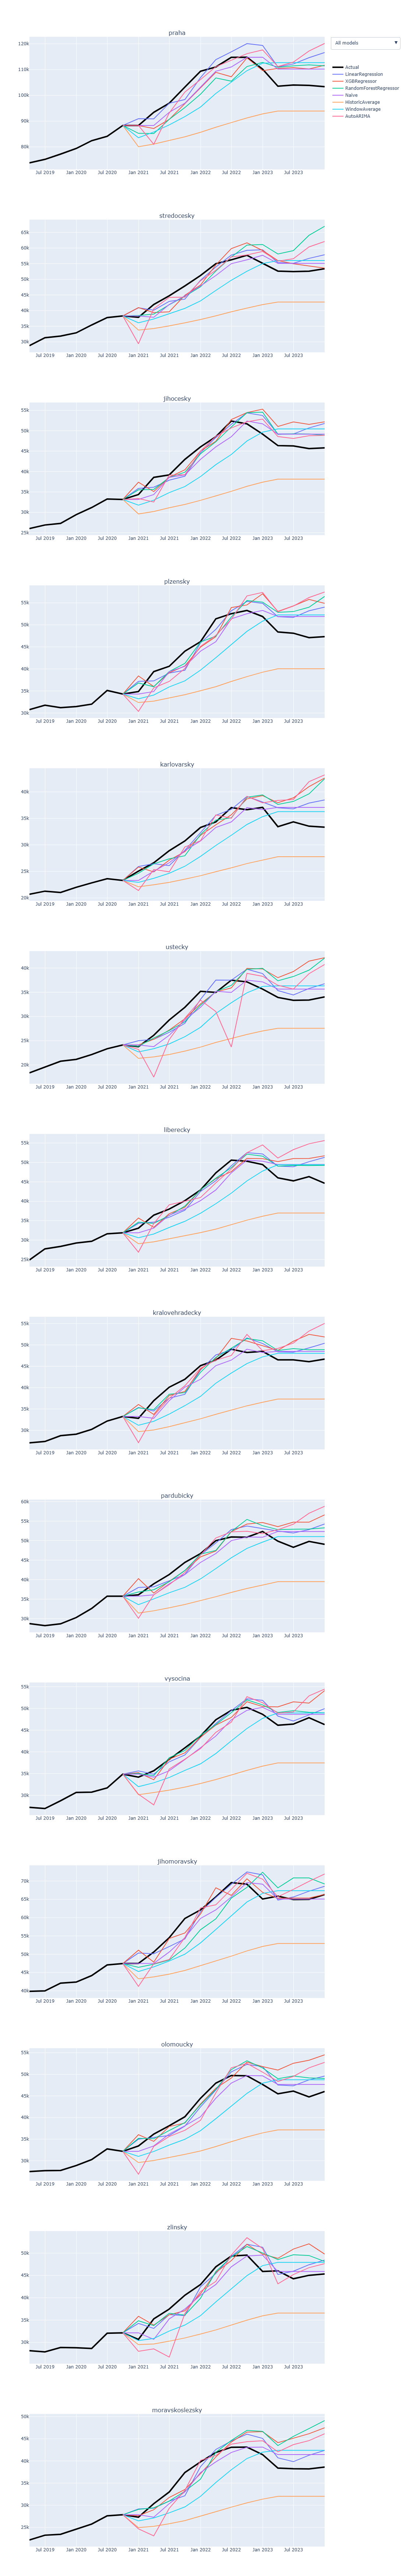

In [18]:
ml_forecasts = (cv_results_ml
    .sort_values("cutoff")
    .groupby(["region", "date"])
    .last()
    .reset_index()
    .drop(columns=["price", "cutoff", "horizon"]))

stat_forecasts = (cv_results_stat
    .sort_values("cutoff")
    .groupby(["region", "date"])
    .last()
    .reset_index()
    .drop(columns=["price", "cutoff", "horizon"]))

combined_forecasts = pd.merge(
    ml_forecasts, 
    stat_forecasts, 
    on=["region", "date"], 
    how="inner"
)

show_graph(df_train, combined_forecasts)

# Prediction

In [19]:
mlf.fit(
    df=df_train,
    id_col='region',
    time_col='date',
    target_col='price',
    static_features=[]
)

sf.fit(
    df=df_train,
    id_col='region',
    time_col='date',
    target_col='price'
)

future_dates = sorted(df['date'].unique())[-4:]  # 2024 Q1–Q4

last_known = (df_train.groupby('region')[['corr_neighbors_change_lag1']]
              .last()
              .reset_index())

X_df = pd.concat([
    last_known.assign(date=date) for date in future_dates
])

predictions_sf = sf.predict(h=4, X_df=X_df)
predictions_ml = mlf.predict(h=4, X_df=X_df)

predictions_arima = predictions_sf[['region', 'date', 'AutoARIMA']]

combined_predictions = pd.merge(
    predictions_ml, 
    predictions_arima, 
    on=['region', 'date'], 
    how='inner'
)

## Graph Vizualization

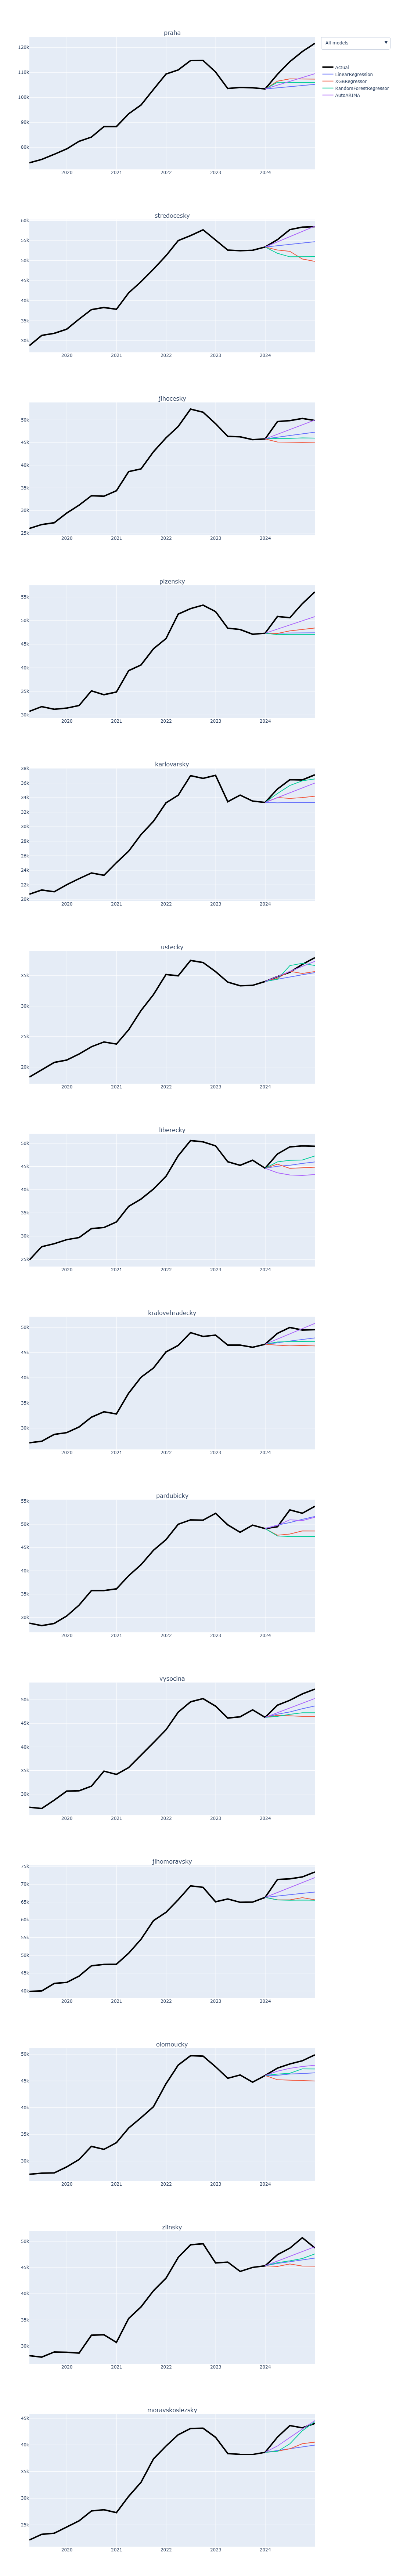

In [20]:
show_graph(df, combined_predictions)

## Prediction Evaluation

In [21]:
# Naive
naive_pred = (df_train.groupby('region')['price']
              .last()
              .reset_index()
              .rename(columns={'price': 'Naive'}))

naive_pred = pd.concat([
    naive_pred.assign(date=date) for date in future_dates
])

combined_predictions = pd.merge(
    combined_predictions,
    naive_pred,
    on=['region', 'date'],
    how='left'
)

df_holdout_eval = df[df['date'].isin(future_dates)][['region', 'date', 'price']]

eval_results = pd.merge(combined_predictions, df_holdout_eval, on=['region', 'date'])

model_cols = [c for c in combined_predictions.columns if c not in ['region', 'date']]

rows = []
for model in model_cols:
    mae  = mean_absolute_error(eval_results['price'], eval_results[model])
    rmse = np.sqrt(mean_squared_error(eval_results['price'], eval_results[model]))
    mae_pct = (mae / eval_results['price'].mean()) * 100
    rows.append({'model': model, 'MAE': round(mae, 0), 'RMSE': round(rmse, 0), 'MAE%': round(mae_pct, 2)})

holdout_table = pd.DataFrame(rows).set_index('model')

display(holdout_table.style
    .format({'MAE': '{:.0f}', 'RMSE': '{:.0f}', 'MAE%': '{:.2f}%'})
    .background_gradient(cmap='Blues', axis=None, subset=['MAE%'])
    .background_gradient(cmap='Purples', axis=None, subset=['RMSE'])
    .set_caption("Model evaluation on holdout (2024 Q1–Q4)")
)

,MAE,RMSE,MAE%
model,,,
LinearRegression,3621,4567,6.65%
XGBRegressor,4265,4922,7.83%
RandomForestRegressor,3753,4826,6.89%
AutoARIMA,2282,3332,4.19%
Naive,4448,5345,8.17%
